In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import matplotlib.pyplot as plt

In [2]:
class SRDataset(Dataset):
    def __init__(self, lr_path, hr_path):
        self.lr_imgs = sorted(os.listdir(lr_path))
        self.hr_imgs = sorted(os.listdir(hr_path))
        self.lr_path = lr_path
        self.hr_path = hr_path

        self.transform = transforms.Compose([
            transforms.Resize((64,64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.lr_imgs)

    def __getitem__(self, idx):
        lr = Image.open(os.path.join(self.lr_path, self.lr_imgs[idx])).convert("RGB")
        hr = Image.open(os.path.join(self.hr_path, self.hr_imgs[idx])).convert("RGB")
        return self.transform(lr), self.transform(hr)

In [3]:
train_data = SRDataset("dataset/train/low_res", "dataset/train/high_res")
loader = DataLoader(train_data, batch_size=16, shuffle=True)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,3,3,padding=1)
        )
    def forward(self,x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*64*64,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.net(x)

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=0.001)
opt_D = torch.optim.Adam(D.parameters(), lr=0.001)

loss_fn = nn.BCELoss()

for epoch in range(7):
    for lr, hr in loader:
        lr, hr = lr.to(device), hr.to(device)

        fake = G(lr)

        real_loss = loss_fn(D(hr), torch.ones_like(D(hr)))
        fake_loss = loss_fn(D(fake.detach()), torch.zeros_like(D(fake)))
        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        g_loss = loss_fn(D(fake), torch.ones_like(D(fake)))

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} GAN Loss: {g_loss.item():.4f}")

Epoch 1 GAN Loss: 0.0000
Epoch 2 GAN Loss: 0.0000
Epoch 3 GAN Loss: 0.0000
Epoch 4 GAN Loss: 0.0000
Epoch 5 GAN Loss: 0.0000
Epoch 6 GAN Loss: 0.0000
Epoch 7 GAN Loss: 0.0000


In [10]:
mse = nn.MSELoss()

for epoch in range(7):
    for lr, hr in loader:
        lr, hr = lr.to(device), hr.to(device)

        fake = G(lr)

        content_loss = mse(fake, hr)
        adv_loss = loss_fn(D(fake), torch.ones_like(D(fake)))

        g_loss = content_loss + 0.001 * adv_loss

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} SRGAN Loss: {g_loss.item():.4f}")

Epoch 1 SRGAN Loss: 0.0377
Epoch 2 SRGAN Loss: 0.0164
Epoch 3 SRGAN Loss: 0.0076
Epoch 4 SRGAN Loss: 0.0096
Epoch 5 SRGAN Loss: 0.0063
Epoch 6 SRGAN Loss: 0.0036
Epoch 7 SRGAN Loss: 0.0031


In [11]:
for epoch in range(7):
    for lr, hr in loader:
        lr, hr = lr.to(device), hr.to(device)

        fake = G(lr)

        loss = mse(fake, hr)

        opt_G.zero_grad()
        loss.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} ESRGAN Loss: {loss.item():.4f}")

Epoch 1 ESRGAN Loss: 0.0041
Epoch 2 ESRGAN Loss: 0.0015
Epoch 3 ESRGAN Loss: 0.0022
Epoch 4 ESRGAN Loss: 0.0033
Epoch 5 ESRGAN Loss: 0.0013
Epoch 6 ESRGAN Loss: 0.0016
Epoch 7 ESRGAN Loss: 0.0010


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.049517676..1.0504363].


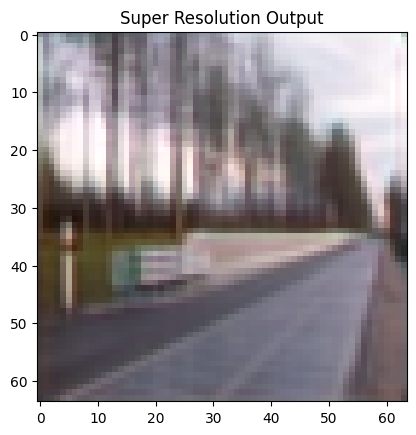

In [12]:
lr, hr = next(iter(loader))
lr = lr.to(device)

fake = G(lr).cpu().detach()

plt.imshow(fake[0].permute(1,2,0))
plt.title("Super Resolution Output")
plt.show()